In [49]:
# import sys
# print(sys.executable)

**Library Installation**

In [50]:
!pip install pytesseract groq tqdm opencv-python-headless pillow -q
!apt-get install tesseract-ocr -q

zsh:1: command not found: apt-get


**Groq setup for LLM Access**

In [51]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Get the project root (one level up from ocr/ notebook directory)
project_root = Path("/Users/grigoriostsakalis/Desktop/UniAI/makeathon-2026-WHOAMI-inform")
env_path = project_root / "ocr" / ".data" / ".env"

# Explicitly point to the .env file (same pattern as RAG pipeline config.py)
load_dotenv(env_path)

api_key = os.environ.get("GROQ_API_KEY", "")
if not api_key:
    raise ValueError(f"❌ GROQ_API_KEY not found in {env_path}. Add it to backend/.env")

**High Level Architectural Diagram**

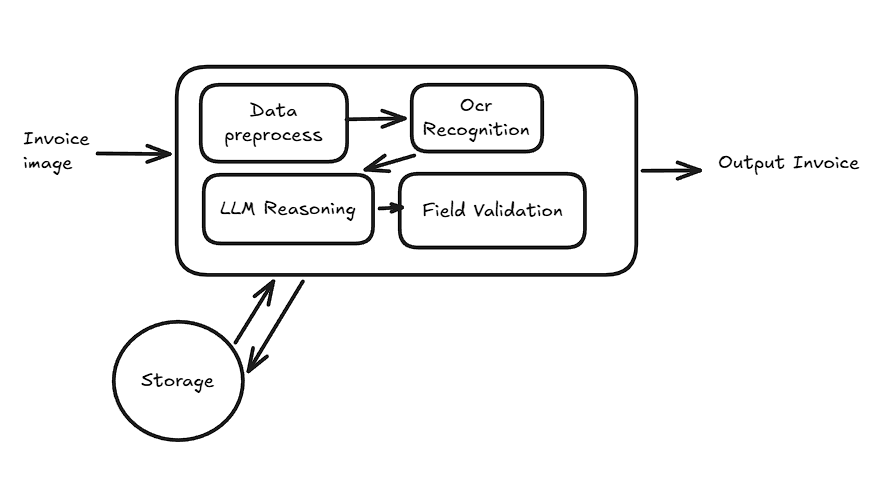

**Step-1 : batch Images read and process**

In [52]:
import os, glob, json, time, re
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import pytesseract
from pytesseract import Output
from groq import Groq
from tqdm import tqdm

ROOT            = "/kaggle/input/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr"
CHECKPOINT_FILE = "/kaggle/working/checkpoint.json"
OUTPUT_CSV      = "/kaggle/working/output.csv"

client = Groq(api_key=api_key)

REQUIRED_FIELDS = [
    "Seller Name", "Seller Tax ID", "Client Name", "Client Tax ID",
    "Invoice Number", "Invoice Date", "Net Worth", "VAT", "Gross Worth"
]

**Step 2:- Load Dataset and ground truth**

In [53]:
batch1_df = pd.read_csv(r"/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv")

In [54]:
display(batch1_df["OCRed Text"].iloc[5])
# SUMMARY VAT [%] Net worth VAT Gross worth 10% 64 161,23 6 416,12 70 577,35 Total $ 64 161,23 $ 6 416,12 $ 70 577,35 Inlay'

'Invoice no: 57290992 Date of issue: 10/03/2011 Seller: Client: Adams PLC Johnson, Daniels and Ramirez USS Moon 6889 Oliver Summit FPO AA 34591 South Ebony, NY 23978 Tax Id: 964-98-1799 Tax Id: 925-71-0496 IBAN: GB3OOLCJ81769735097340 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 25"x25 Marble Black Top 5,00 each 2 789,00 13 945,00 10% 15 339,50 custom Table Carnelian Marquetry Art Halloween Gift 2 7\'x4 Blue Random Marble 3,00 each 8 194,09 24 582,27 10% 27 040,50 Dining Hallway Table Top Lapis Lazuli Decor E947A 3 6\'x3\' White Marble Dining Table 4,00 each 6 408,49 25 633,96 10% 28 197,36 Top Multi Inlay Floral Elephant Art Decor H4952 SUMMARY VAT [%] Net worth VAT Gross worth 10% 64 161,23 6 416,12 70 577,35 Total $ 64 161,23 $ 6 416,12 $ 70 577,35 Inlay'

In [55]:
def discover_dataset(root):
    """
    Loads 50 images specified in the assignment.
    batch1-0331 to batch1-0381 inside batch_1/batch_1/batch1_1/
    """
    img_dir     = os.path.join(root, "batch_1", "batch_1", "batch1_1") # folder batch1_1 contains images
    csv_path    = os.path.join(root, "batch_1", "batch_1", "batch1_1.csv") # csv file located at the same directory as the img folder above

    dataset = []

    for i in range(331, 381):                          # 0331 to 0381 inclusive
        filename = f"batch1-{str(i).zfill(4)}.jpg"    # zero-padded e.g. batch1-0331.jpg
        img_path = os.path.join(img_dir, filename)

        if os.path.exists(img_path):
            dataset.append({
                "img_path" : img_path,
                "filename" : filename,
                "batch"    : "batch_1",
                "csv_path" : csv_path if os.path.exists(csv_path) else None,
            })
        else:
            print(f"Not found: {filename}")

    print(f"Loaded {len(dataset)} images (assignment scope: 50)")
    return dataset

ROOT = r"/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/"
dataset = discover_dataset(ROOT)

Loaded 50 images (assignment scope: 50)


In [56]:
for i in range(5):
    print(dataset[i])

{'img_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0331.jpg', 'filename': 'batch1-0331.jpg', 'batch': 'batch_1', 'csv_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv'}
{'img_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0332.jpg', 'filename': 'batch1-0332.jpg', 'batch': 'batch_1', 'csv_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv'}
{'img_path': '/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0333.jpg', 'filename': 'batch1-0333.jpg', 'batch': 'bat

In [57]:
def load_ground_truth(csv_path):
    """
    Loads a ground truth CSV into a dict keyed by filename.
    Handles both 'filename' and 'image' column names.
    gt_lookup is a directory in which each key is an image.
    Each image's values are the ground truth (correct) data that the ocr model
    should return.
    Therefore this is a great way to compare, evaluate, and calculate accuracy
    metrics for the performance of the ocr model.
    """
    if not csv_path or not os.path.exists(csv_path):
        return {}
        
    df = pd.read_csv(csv_path)
    print(f"GT columns found: {list(df.columns)}")
    df.head(5)
 
    gt_lookup = {}
    for _, row in df.iterrows():
        # Try common key column names
        key = str(
            row.get("filename") or
            row.get("image")    or
            row.get("file")     or
            row.iloc[0]
        )
        gt_lookup[key] = row.to_dict()
 
    return gt_lookup
 
 
# Preview one ground truth CSV so you can see its structure
sample_csv = next((d["csv_path"] for d in dataset if d["csv_path"]), None)
if sample_csv:
    print(f"\nPreviewing: {sample_csv}\n")
    display(pd.read_csv(sample_csv).head(3))


Previewing: /Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1.csv



,File Name,Json Data,OCRed Text
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...


**Step 3:- Image Preprocess and extraction**

In [58]:
def preprocess(img_path):
    """
    Grayscale + Otsu thresholding + slight dilation.
    Dramatically improves Tesseract accuracy on invoice scans.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Slight dilation to reconnect broken characters
    kernel = np.ones((1, 1), np.uint8)
    img    = cv2.dilate(img, kernel, iterations=1)
    return img
 
def extract_text(img):
    """
    Reconstructs invoice layout using word-level positional data.
    Handles two-column layouts by grouping words into rows by vertical
    proximity, then sorting each row left-to-right with column spacing.
    """
    dict_data = pytesseract.image_to_data(img, output_type=Output.DICT)
    df = pd.DataFrame(dict_data)
    df = df[(df["conf"] != -1) & (df["text"].str.strip() != "")].copy()
    df["conf"] = df["conf"].astype(int)

    if df.empty:
        return "", dict_data

    df = df.sort_values(by=["top", "left"]).reset_index(drop=True)
    rows = []
    current_row = [df.iloc[0]]

    for i in range(1, len(df)):
        word = df.iloc[i]
        last = current_row[-1]
        same_line = abs(word["top"] - last["top"]) <= 12

        if same_line:
            current_row.append(word)
        else:
            rows.append(current_row)
            current_row = [word]

    rows.append(current_row)
    all_lefts = df["left"].values
    page_width = int(df["left"].max() + df["width"].max())
    midpoint   = page_width // 2
    raw_text = ""

    for row_words in rows:
        row_words_sorted = sorted(row_words, key=lambda w: w["left"])
        line = ""
        prev_right = 0  
        for word in row_words_sorted:
            left  = word["left"]
            text  = word["text"]
            width = word["width"]

            # Calculate gap between previous word and this one
            gap = left - prev_right

            if prev_right == 0:
                line += text
            elif gap > midpoint * 0.2:
                line += "\t" + text
            elif gap > 15:
                line += " " + text
            else:
                line += " " + text

            # line += "\t" + text

            prev_right = left + width

        raw_text += line.strip() + "\n"

    return raw_text.strip(), dict_data

**Test sample image**

/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0372.jpg
Sample Invoice Image


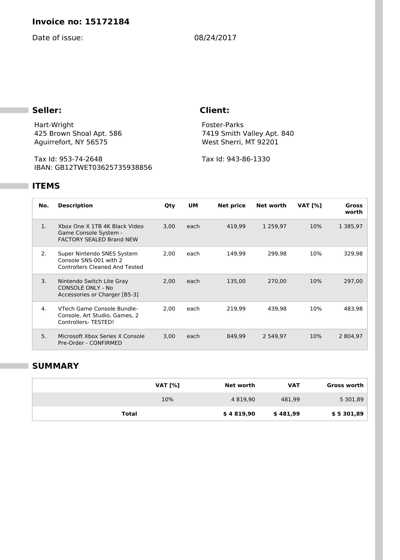


 Raw OCR Output
Invoice no: 15172184
Date of issue:	08/24/2017
Seller:	Client:
Hart-Wright	Foster-Parks
425 Brown Shoal Apt. 586	7419 Smith Valley Apt. 840
Aguirrefort, NY 56575	West Sherri, MT 92201
Tax Id: 953-74-2648	Tax Id: 943-86-1330
IBAN: GB12TWET03625735938856
ITEMS
No. Description	Qty UM Net price Net worth VAT [%] Gross
worth
1. Xbox One X 1TB 4K Black Video 3,00 eac h 419,99 1 259,97 10% 1 385,97
Game Console System -
FACTORY SEALED Brand NEW
2. Super Nintendo SNES System 2,00 eac 149,99 299,98 10% 329,98
Console SNS-001 with 2
Controllers Cleaned And Tested
3. Nintendo Switch Lite Gray 2,00 eac 135,00 270,00 10% 297,00
CONSOLE ONLY - No
Accessories or Charger [B5-3]
4, VTech Game Console Bundle- 2,00 eac 219,99 439,98 10% 483,98
Console, Art Studio, Games, 2
Controllers- TESTED!
5. Microsoft Xbox Series X Console 3,00 eac 849,99 2 549,97 10% 2 804,97
Pre-Order - CONFIRMED
SUMMARY
VAT [%]	Net worth VAT Gross worth
10%	4 819,90 481,99 5 301,89
Total	$4 819,90 $ 481,99 $5 301

In [59]:
# sample_img_path = dataset[10]["img_path"]
sample_img_path = "/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0372.jpg"
print(sample_img_path)
sample_img      = preprocess(sample_img_path)
sample_text , sample_dict    = extract_text(sample_img)
print("Sample Invoice Image")
display(Image.open(sample_img_path).resize((400, 560)))
print("\n Raw OCR Output")
print(sample_text)

**Step 4:- Extract Fields via LLM & reasoning**

In [60]:
def structure_for_llm(raw_text):
    """
    Converts tab-separated two-column OCR text into
    explicitly labelled SELLER/CLIENT blocks for the LLM.
    Removes spatial ambiguity entirely before the LLM sees it.
    """
    seller_lines = []
    client_lines = []
    general_lines = []
    
    for line in raw_text.split("\n"):
        if not line.strip():
            continue
        if "\t" in line and not "Date" in line:
            parts = [p.strip() for p in line.split("\t", 1)]
            left  = parts[0] if len(parts) > 0 else ""
            right = parts[1] if len(parts) > 1 else ""
            if left:  seller_lines.append(left)
            if right: client_lines.append(right)
        else:
            general_lines.append(line.strip())

    structured = ""

    if seller_lines:
        structured += "=== SELLER BLOCK ===\n"
        structured += "\n".join(seller_lines) + "\n\n"

    if client_lines:
        structured += "=== CLIENT BLOCK ===\n"
        structured += "\n".join(client_lines) + "\n\n"

    if general_lines:
        structured += "=== INVOICE DETAILS ===\n"
        structured += "\n".join(general_lines) + "\n"

    return structured

In [61]:
def extract_fields_llm(raw_text:str):
    """
    Sends OCR text to Groq and gets structured fields back as JSON.
    Temperature=0 for deterministic extraction.
    """
    prompt = f"""
You are an expert invoice field extractor. Your task is to identify and extract numeric financial fields from messy OCR text.

CRITICAL INVOICE STRUCTURE:
Every invoice has exactly ONE "Total" line that contains the three financial amounts you need.
This Total line appears at the end of the invoice (NOT in summary sections or headers).
Format: "Total" keyword followed by exactly 3 numeric values in this EXACT order:
  1st value = Net Worth (subtotal before tax)
  2nd value = VAT/Tax Amount (tax in currency units, NOT percentage)
  3rd value = Gross Worth (final total after adding tax)

IMPORTANT: The Total line has multiple currency symbols separated by spaces. Parse left-to-right, extracting exactly 3 amounts.

REAL EXAMPLES FROM ACTUAL INVOICES (use these as reference):
Example 1:
  Line: "Total    $ 84 944,82 $ 8 494,48 $ 93 439,30"
  → Net Worth: 84944.82
  → VAT: 8494.48
  → Gross Worth: 93439.30
  (Note: "$ 84 944,82" has space before the number AND space inside the number)

Example 2:
  Line: "Total	$4 819,90 $ 481,99 $5 301,89"
  → Net Worth: 4819.90
  → VAT: 481.99
  → Gross Worth: 5301.89
  (Note: "$4 819,90" - currency touches number but number has internal space)

Example 3:
  Line: "Total          $5 992,66   $ 599,27   $ 6 591,93"
  → Net Worth: 5992.66
  → VAT: 599.27
  → Gross Worth: 6591.93

PARSING ALGORITHM FOR TOTAL LINE:
1. Find the word "Total" in the text
2. Extract everything after "Total" on that line
3. Split by "$" symbol (this separates the 3 amounts)
4. You will get 4 parts: [empty prefix, amount1, amount2, amount3]
5. For each amount:
   a) Remove ALL whitespace (including internal spaces): " 84 944,82" → "84944,82"
   b) Replace comma with dot: "84944,82" → "84944.82"
   c) Convert to float: 84944.82
6. Return as: [amount1, amount2, amount3]

DISTINGUISH BETWEEN:
- SUMMARY section: Contains VAT percentage (e.g., "10%") — IGNORE THIS, it's not the amounts you need
- TOTAL line: Contains VAT amount in currency (€, $, £, or just numbers) — USE THIS
- Lines with "Subtotal" or "Net amount": May appear before Total — these are LESS reliable than Final Total

FIELDS TO EXTRACT:
- Seller Name: Company or person name on invoice (NOT address)
- Seller Tax ID: VAT/Tax ID near seller info
- Client Name: Billing customer name (NOT address)
- Client Tax ID: VAT/Tax ID near client info
- Invoice Number: Reference code (labeled "Invoice no", "Invoice #", "Ref", "Invoice ID", etc.)
- Invoice Date: When issued (return as YYYY-MM-DD only)
- Net Worth: First numeric value from FINAL Total line (amount before tax)
- VAT: Second numeric value from FINAL Total line (tax amount in currency, never a percentage)
- Gross Worth: Third numeric value from FINAL Total line (final total)

NUMBER CLEANING RULES (CRITICAL — apply to all amounts):
Step 1: Remove ALL spaces (both leading and internal): " 84 944,82" → "84944,82"
Step 2: Replace comma with dot if present: "84944,82" → "84944.82"
Step 3: Strip any remaining non-digit characters except the decimal point
Step 4: Convert to float

CRITICAL EXAMPLES OF NUMBER CLEANING:
- " 84 944,82" → remove spaces → "84944,82" → replace comma → 84944.82 ✓
- "$4 819,90" → remove $ → "4 819,90" → remove spaces → "4819,90" → replace comma → 4819.90 ✓
- "$ 481,99" → remove $ and space → "481,99" → replace comma → 481.99 ✓
- "$5 301,89" → remove $ → "5 301,89" → remove spaces → "5301,89" → replace comma → 5301.89 ✓
- "€1.234,50" → remove € → "1.234,50" → remove dot (thousands separator) → "1234,50" → replace comma → 1234.50 ✓

VALIDATION & SELF-CORRECTION:
After extraction, verify: Net Worth + VAT ≈ Gross Worth (within 0.1 tolerance to account for rounding)

If they don't balance, one value is corrupted:
- Example: Net=84944.82, VAT=8494.48, Gross=93939.30
- Check: 84944.82 + 8494.48 = 93439.30 (should be), but got 93939.30 (error of 500)
- This suggests Gross has OCR error. Fix: Gross = 84944.82 + 8494.48 = 93439.30

Priority for self-correction:
1. Trust the two values that are closest to matching when summed
2. If Net + VAT ≠ Gross:
   - Assume Gross is wrong: Gross = Net + VAT
   OR
   - Assume VAT is wrong: VAT = Gross - Net
   OR
   - Assume Net is wrong: Net = Gross - VAT

HANDLING AMBIGUOUS TEXT:
- If multiple "Total" lines exist, use the LAST one (it's the final total)
- Ignore lines with percentages (%), those are from SUMMARY sections
- Ignore "Subtotal" lines unless no "Total" exists
- ALWAYS count the exact number of "$" symbols to ensure you have exactly 3 amounts

OUTPUT FORMAT:
Return raw JSON only. No markdown. No explanation. Use exact field names. Use null for missing fields.
Return numbers as plain floats (not strings).
Return dates as YYYY-MM-DD strings.

Recheck your extraction:
- Did you find exactly 3 numeric amounts from the Total line?
- Did you remove ALL spaces from each amount?
- Did you convert commas to dots?
- Do the numbers add up correctly (Net + VAT ≈ Gross)?

OCR TEXT:
{raw_text}
"""

    response = client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct", # llama-3.1-8b-instant
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0,
    )
    return json.loads(response.choices[0].message.content)

***LLM Fallback Logic***

In [62]:
def regex_extraction_llm_fallback(structured_text):

    def get_block(label):
        m = re.search(rf'=== {label}.*?===\n(.*?)(?====|\Z)', structured_text, re.DOTALL)
        return m.group(1).strip() if m else ""

    def find(pattern, text):
        m = re.search(pattern, text, re.I | re.MULTILINE)
        return m.group(1).strip() if m else None

    def clean_num(val):
        if not val: return None
        val = re.sub(r'[$€£\s]', '', val).replace(',', '.')
        try:    return float(val)
        except: return None

    seller  = get_block("SELLER")
    client  = get_block("CLIENT")
    details = get_block("INVOICE DETAILS")

    return {
        "Seller Name"    : find(r'^([A-Za-z][\w\s\-\.]+)$', seller),
        "Seller Tax ID"  : find(r'Tax\s*Id[:\s]+([0-9\-]+)', seller),
        "Client Name"    : find(r'^([A-Za-z][\w\s\-\.]+)$', client),
        "Client Tax ID"  : find(r'Tax\s*Id[:\s]+([0-9\-]+)', client),
        "Invoice Number" : find(r'Invoice\s*no[:\s]+([A-Z0-9\-]+)', details),
        "Invoice Date"   : find(r'(\d{2}[\/\-]\d{2}[\/\-]\d{4})', details),
        "Net Worth"      : clean_num(find(r'Total\s+\$?\s*([\d\s,\.]+?)\s+\$', details)),
        "VAT"            : clean_num(find(r'Total\s+\$?[\d\s,\.]+\$\s*([\d\s,\.]+?)\s+\$', details)),
        "Gross Worth"    : clean_num(find(r'Total\s+.*\$\s*([\d\s,\.]+)$', details)),
    }

**Step 5:- Field validation**

In [63]:
def validate_fields(fields):
    validation = {}

    for field in REQUIRED_FIELDS:
        val = fields.get(field)

        if val is None or str(val).strip() in ("", "null", "None"):
            validation[f"{field}_valid"] = False
            continue

        if field in ("Net Worth", "VAT", "Gross Worth"):
            try:
                float(str(val).replace(",", "").replace(" ", ""))
                validation[f"{field}_valid"] = True
            except ValueError:
                validation[f"{field}_valid"] = False

        elif field == "Invoice Date":
            validation[f"{field}_valid"] = bool(
                re.search(r"\d{2,4}[-/\.]\d{1,2}[-/\.]\d{1,4}", str(val))
            )

        else:
            validation[f"{field}_valid"] = True

    # ── Fix: only check field flags, not all_fields_found itself ──
    field_flags = [validation[f"{f}_valid"] for f in REQUIRED_FIELDS]
    validation["all_fields_found"] = all(field_flags)

    return validation

***Whole Image extraction & Data Validation Pipeline***

In [64]:
def extract_fields(structured_text):
    """
    Stage 1: LLM extraction
    Stage 2: Regex fills any null fields LLM missed
    Stage 3: If LLM fails entirely, regex takes over
    """
    regex_fields = regex_extraction_llm_fallback(structured_text)

    try:
        llm_fields = extract_fields_llm(structured_text)

        # ── Fill null LLM fields from regex ───────────────────────
        for field in REQUIRED_FIELDS:
            if not llm_fields.get(field) and regex_fields.get(field):
                print(f"   '{field}' null from LLM → filled by regex: {regex_fields[field]}")
                llm_fields[field] = regex_fields[field]

        return llm_fields

    except Exception as e:
        print(f"⚠️  LLM failed entirely → using regex: {e}")
        return regex_fields
    

def run_pipeline(dataset, rate_limit_delay=0.8):
    results = []

    # ── Pre-load all ground truth CSVs ────────────────────────────
    gt_cache = {}
    for entry in dataset:
        cp = entry["csv_path"]
        if cp and cp not in gt_cache:
            gt_cache[cp] = load_ground_truth(cp)

    print(f"Total images to process: {len(dataset)}")

    for entry in tqdm(dataset, desc="Processing invoices"):
        img_path = entry["img_path"]
        filename = entry["filename"]

        try:
            # ── Stage 1: Preprocess + OCR ─────────────────────────
            img                 = preprocess(img_path)
            raw_text, dict_data = extract_text(img)

            # ── Stage 2: Structure ────────────────────────────────
            structured_text     = structure_for_llm(raw_text)
            # if img_path == "/Users/grigoriostsakalis/.cache/kagglehub/datasets/osamahosamabdellatif/high-quality-invoice-images-for-ocr/versions/3/batch_1/batch_1/batch1_1/batch1-0359.jpg":
            #     print(structured_text)
            #     exit(0)
            # else:
            #     continue

            # ── Stage 3: Extract (LLM + regex fallback combined) ──
            fields              = extract_fields(structured_text)

            # ── Stage 4: Validate (warnings only) ─────────────────
            validation          = validate_fields(fields)
            missing             = [f for f in REQUIRED_FIELDS if not validation[f"{f}_valid"]]
            if missing:
                print(f"\n⚠️  [{filename}] missing: {missing}")

            # ── Stage 5: Build row ────────────────────────────────
            row = {
                "filename" : filename,
                **{f: fields.get(f) for f in REQUIRED_FIELDS},
            }

        except Exception as e:
            print(f"\n❌ [{filename}]: {e}")
            row = {
                "filename" : filename,
                **{f: None for f in REQUIRED_FIELDS},
            }

        results.append(row)
        time.sleep(rate_limit_delay)

    return results


# ── Run ────────────────────────────────────────────────────────────
results = run_pipeline(dataset)

# ── Save output.csv ────────────────────────────────────────────────
df = pd.DataFrame(results)[["filename"] + REQUIRED_FIELDS]
df.to_csv(".data/working/output.csv", index=False)

print(f"\n✅ Done: {len(df)} invoices → output.csv")
display(df.head(10))

GT columns found: ['File Name', 'Json Data', 'OCRed Text']
Total images to process: 50


Processing invoices: 100%|██████████| 50/50 [02:15<00:00,  2.70s/it]


✅ Done: 50 invoices → output.csv


,filename,Seller Name,Seller Tax ID,Client Name,Client Tax ID,Invoice Number,Invoice Date,Net Worth,VAT,Gross Worth
0,batch1-0331.jpg,Ochoa-Scott,921-82-1053,Green LLC,965-99-1263,94138597,2018-02-05,1612.50,161.25,1773.75
1,batch1-0332.jpg,Chavez Ltd,904-77-6503,Roberts Ltd,956-94-0439,13507183,2015-09-09,1026.72,102.67,1129.39
2,batch1-0333.jpg,"Solomon, Ford and Ellis",954-73-2478,Hamilton-Jackson,988-96-5706,74819543,2020-10-07,125.00,12.50,137.50
3,batch1-0334.jpg,Duncan Ltd,964-84-8594,Edwards-Archer,909-91-4017,65498230,2021-02-16,45.50,4.55,50.05
4,batch1-0335.jpg,Johnson-Brooks,964-92-2746,"Proctor, Morgan and Williams",939-82-6262,51467723,2019-04-21,96817.20,9681.72,106498.92
5,batch1-0336.jpg,Decker PLC,957-87-4031,Boyle Ltd,993-86-3706,97511742,2016-04-07,4314.93,431.49,4746.42
6,batch1-0337.jpg,"Snyder, Bryan and Booth",983-70-0913,Ashley-Perry,981-88-6259,94098997,2020-04-10,13846.77,1384.68,15231.45
7,batch1-0338.jpg,Bailey PLC,918-95-6591,Turner Inc,998-92-7755,11926242,2012-03-01,3340.47,334.05,3674.52
8,batch1-0339.jpg,Rodriguez-Barnett,986-88-3758,"Le, Lawson and Rios",967-80-5679,48531206,2019-08-03,5587.91,558.79,6146.70
9,batch1-0340.jpg,Daniel-Morrison,995-99-6193,"Snyder, Benton and Reed",999-86-4010,82977013,2013-06-12,244.99,24.50,269.49


In [65]:
display(df.loc[df["filename"] == "batch1-0345.jpg"])
# batch1_df
to_print = batch1_df.loc[batch1_df["File Name"] == "batch1-0345.jpg"]

print(to_print["OCRed Text"])

,filename,Seller Name,Seller Tax ID,Client Name,Client Tax ID,Invoice Number,Invoice Date,Net Worth,VAT,Gross Worth
14,batch1-0345.jpg,Jones and Sons,952-76-3987,Hamilton-Simmons,992-84-7640,92919413,2020-04-10,5992.66,599.27,6591.93


400    Invoice no: 92919413 Date of issue: 10/04/2020...
Name: OCRed Text, dtype: str


# output.csv to requested json format
Example
[
  {
    "doc_id": "inv_001",
    "doc_type": "invoice",
    "vendor": "Adobe",
    "vendor_normalized": "adobe",
    "invoice_number": "ADB-2024-04-1182",
    "invoice_date": "2024-04-12",
    "due_date": "2024-05-12",
    "currency": "USD",
    "subtotal": 89.99,
    "tax": 0.00,
    "total": 89.99,
    "status": "paid",
    "line_items": [
      {"description": "Creative Cloud Teams April 2024", "qty": 1, "unit_price": 89.99, "line_total": 89.99}
    ],
    "raw_text": "Adobe Creative Cloud Teams April 2024 invoice..."
  },
  {
    "doc_id": "inv_002",
    "doc_type": "invoice",
    "vendor": "Adobe",
    "vendor_normalized": "adobe",
    "invoice_number": "ADB-2025-03-7714",
    "invoice_date": "2025-03-09",
    "due_date": "2025-04-09",
    "currency": "USD",
    "subtotal": 104.99,
    "tax": 0.00,
    "total": 104.99,
    "status": "paid",
    "line_items": [
      {"description": "Creative Cloud Teams March 2025", "qty": 1, "unit_price": 104.99, "line_total": 104.99}
    ],
    "raw_text": "Adobe Creative Cloud Teams March 2025 invoice..."
  },
  {
    "doc_id": "rcpt_003",
    "doc_type": "receipt",
    "vendor": "Athens Office Supplies",
    "vendor_normalized": "athens office supplies",
    "invoice_date": "2025-03-10",
    "currency": "EUR",
    "subtotal": 42.50,
    "tax": 10.20,
    "total": 52.70,
    "status": "captured",
    "line_items": [
      {"description": "Printer paper A4", "qty": 5, "unit_price": 5.00, "line_total": 25.00},
      {"description": "Black ink cartridge", "qty": 1, "unit_price": 17.50, "line_total": 17.50}
    ],
    "raw_text": "Retail receipt from Athens Office Supplies..."
  }
]

In [66]:
import json

# ── Read the output CSV ────────────────────────────────────────────
output_df = pd.read_csv(r"/Users/grigoriostsakalis/Desktop/UniAI/makeathon-2026-WHOAMI-inform/ocr/.data/working/output.csv")

# ── Convert to desired JSON format ─────────────────────────────────
documents = []

for idx, row in output_df.iterrows():
    doc = {
        "doc_id": f"inv_{str(idx + 1).zfill(3)}",
        "doc_type": "invoice",
        "vendor": row["Seller Name"] if pd.notna(row["Seller Name"]) else None,
        "vendor_normalized": str(row["Seller Name"]).lower() if pd.notna(row["Seller Name"]) else None,
        "invoice_number": row["Invoice Number"] if pd.notna(row["Invoice Number"]) else None,
        "invoice_date": row["Invoice Date"] if pd.notna(row["Invoice Date"]) else None,
        "currency": "EUR",  # Default currency - adjust if needed
        "subtotal": float(row["Net Worth"]) if pd.notna(row["Net Worth"]) else None,
        "tax": float(row["VAT"]) if pd.notna(row["VAT"]) else None,
        "total": float(row["Gross Worth"]) if pd.notna(row["Gross Worth"]) else None,
        "status": "captured",  # Default status
        "line_items": [],  # Would need more granular data to populate
        "raw_text": "",  # Would need to store raw OCR text from pipeline
        "client_name": row["Client Name"] if pd.notna(row["Client Name"]) else None,
        "client_tax_id": row["Client Tax ID"] if pd.notna(row["Client Tax ID"]) else None,
        "seller_tax_id": row["Seller Tax ID"] if pd.notna(row["Seller Tax ID"]) else None,
    }
    documents.append(doc)

# ── Save as JSON ───────────────────────────────────────────────────
output_json_path = r"/Users/grigoriostsakalis/Desktop/UniAI/makeathon-2026-WHOAMI-inform/ocr/.data/tesseract_validation/invoices.json"

with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(documents, f, indent=2, ensure_ascii=False)

print(f"✅ Converted {len(documents)} invoices → {output_json_path}")

# ── Preview first 2 documents ──────────────────────────────────────
print("\nPreview of first invoice:")
display(documents[0] if documents else "No documents")

✅ Converted 50 invoices → /Users/grigoriostsakalis/Desktop/UniAI/makeathon-2026-WHOAMI-inform/ocr/.data/tesseract_validation/invoices.json

Preview of first invoice:


{'doc_id': 'inv_001',
 'doc_type': 'invoice',
 'vendor': 'Ochoa-Scott',
 'vendor_normalized': 'ochoa-scott',
 'invoice_number': 94138597,
 'invoice_date': '2018-02-05',
 'currency': 'EUR',
 'subtotal': 1612.5,
 'tax': 161.25,
 'total': 1773.75,
 'status': 'captured',
 'line_items': [],
 'raw_text': '',
 'client_name': 'Green LLC',
 'client_tax_id': '965-99-1263',
 'seller_tax_id': '921-82-1053'}

In [67]:
import requests
import os
import json

api_key = os.environ.get("GROQ_API_KEY")
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)
data = response.json()  # Parse JSON once

# Extract just the IDs
models = [print(model["id"], "\n") for model in data["data"]]



groq/compound-mini 

groq/compound 

meta-llama/llama-prompt-guard-2-86m 

meta-llama/llama-prompt-guard-2-22m 

whisper-large-v3-turbo 

meta-llama/llama-4-scout-17b-16e-instruct 

llama-3.3-70b-versatile 

qwen/qwen3-32b 

openai/gpt-oss-120b 

canopylabs/orpheus-arabic-saudi 

llama-3.1-8b-instant 

whisper-large-v3 

openai/gpt-oss-safeguard-20b 

canopylabs/orpheus-v1-english 

allam-2-7b 

openai/gpt-oss-20b 

